# The Perceptron Algorithm

The **perceptron** is one of the earliest and most fundamental algorithms in machine learning and neural networks. Invented by Frank Rosenblatt in 1958, it is a **single-layer neural network** designed for binary classification tasks.

### Key Ideas
- The perceptron takes a set of input features, multiplies each by a learned weight, sums them up (with a bias), and applies a step function to produce a binary output.
- It is a **linear classifier**: it finds a hyperplane that separates two classes.
- The **Perceptron Convergence Theorem** guarantees that if the data is **linearly separable**, the algorithm will converge to a solution in finite steps.

### Limitations
- The perceptron **cannot** solve problems where the data is not linearly separable (the classic example is the **XOR problem**, demonstrated by Minsky & Papert in 1969).
- This limitation motivated the development of **multi-layer perceptrons** (MLPs) and modern deep learning.

---

## 1. Linear Separability

A dataset is **linearly separable** if there exists a straight line (in 2D), a plane (in 3D), or a hyperplane (in higher dimensions) that can perfectly separate the two classes.

Below is an example of linearly separable data:

In [ ]:
from IPython.display import Image
Image(filename='1.1.Linearly_Separable.png')

And here is an example of data that is **not** linearly separable — no single straight line can separate the two classes:

In [ ]:
from IPython.display import Image
Image(filename='1.2.Linearly_unseparable.png')

**Takeaway:** After examining the data, we must determine whether it is linearly separable before deciding to use a perceptron. If the data is not linearly separable, the perceptron will never converge.

---

## 2. The Modeling Paradigm: Inputs/Outputs and Parameter Optimization

The core idea of supervised learning can be framed as **I/O and parameter optimization**:
- **Inputs (I):** Feature vectors from the training data
- **Outputs (O):** Predicted class labels
- **Parameters:** Weights and bias that are iteratively adjusted to minimize prediction error

The perceptron learns by adjusting its weights so that the weighted sum of inputs correctly classifies each training example.

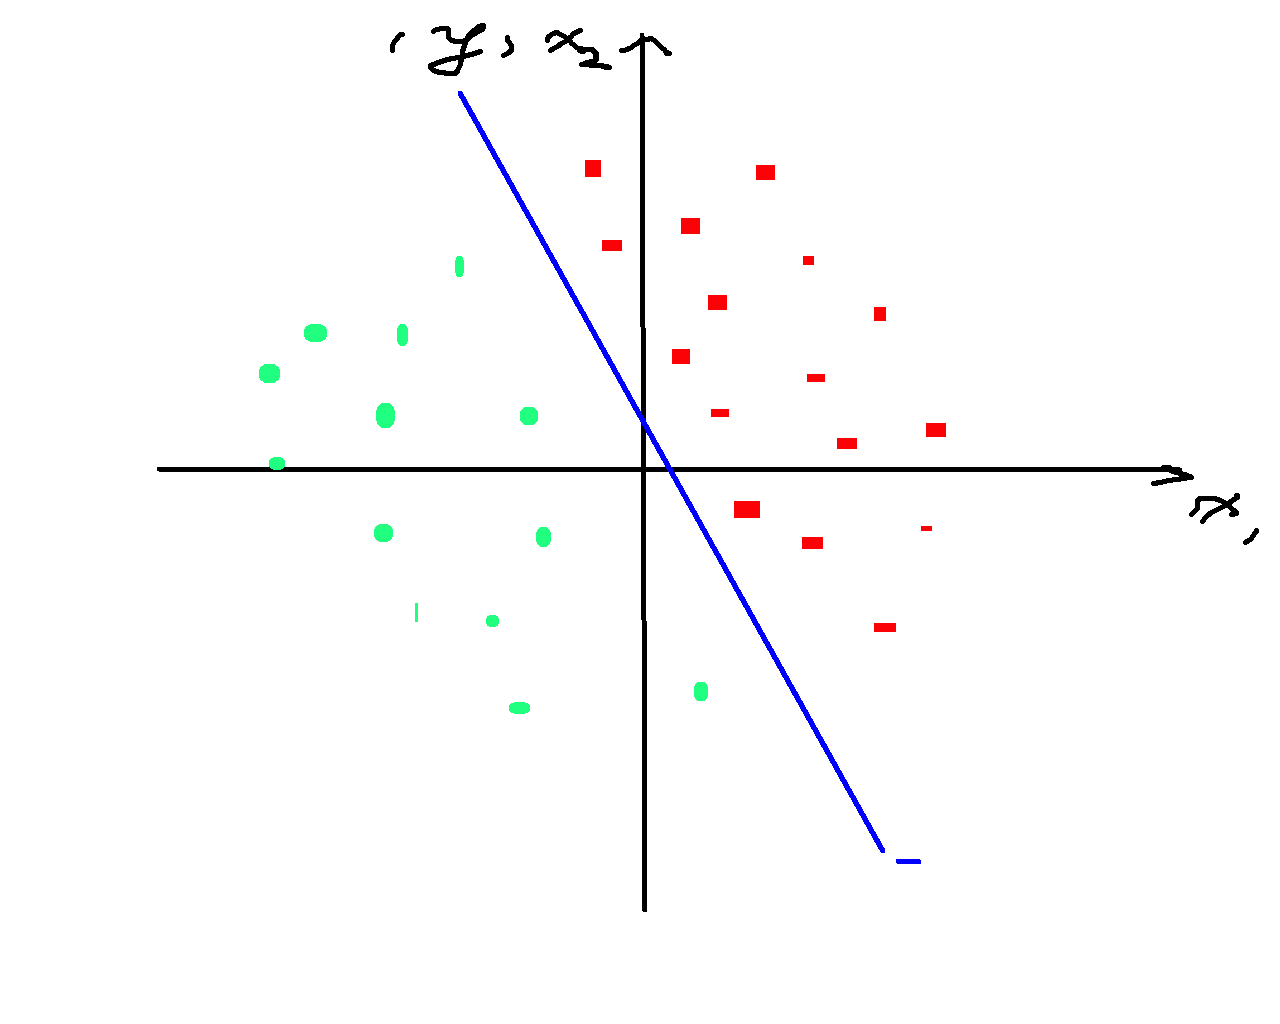

In [ ]:
from IPython.display import Image
Image(filename='1.3.IOandPara.png')

## 3. The Mathematics of the Perceptron

The perceptron computes a weighted sum of the inputs plus a bias term. If this value (the **activation**) is above a threshold (typically 0), the output is class 1; otherwise, class 0.

In [ ]:
from IPython.display import Image
Image(filename='1.4.somemath.png')

### Efficient computation via matrix transpose and dot product

Instead of looping through each weight and input, we can use the **dot product** of the weight vector and the input vector. This is both mathematically elegant and computationally efficient.

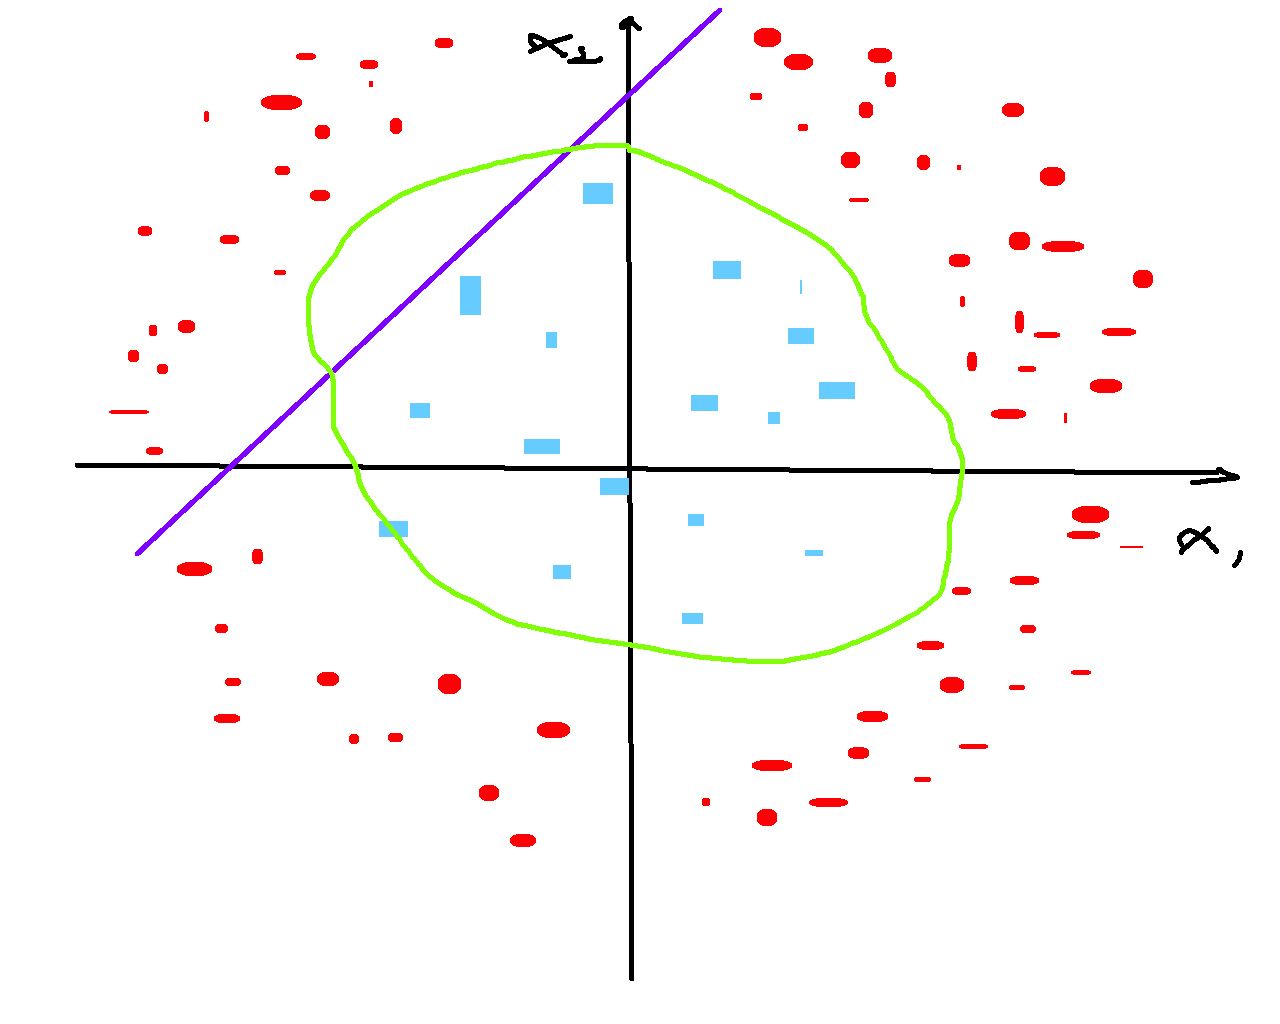

In [ ]:
from IPython.display import Image
Image(filename='1.5.update.png')

In [ ]:
from IPython.display import Image
Image(filename='1.6.update2.png')

In [ ]:
from IPython.display import Image
Image(filename='1.7.update3.png')

In [ ]:
from IPython.display import Image
Image(filename='1.8.update4.png')

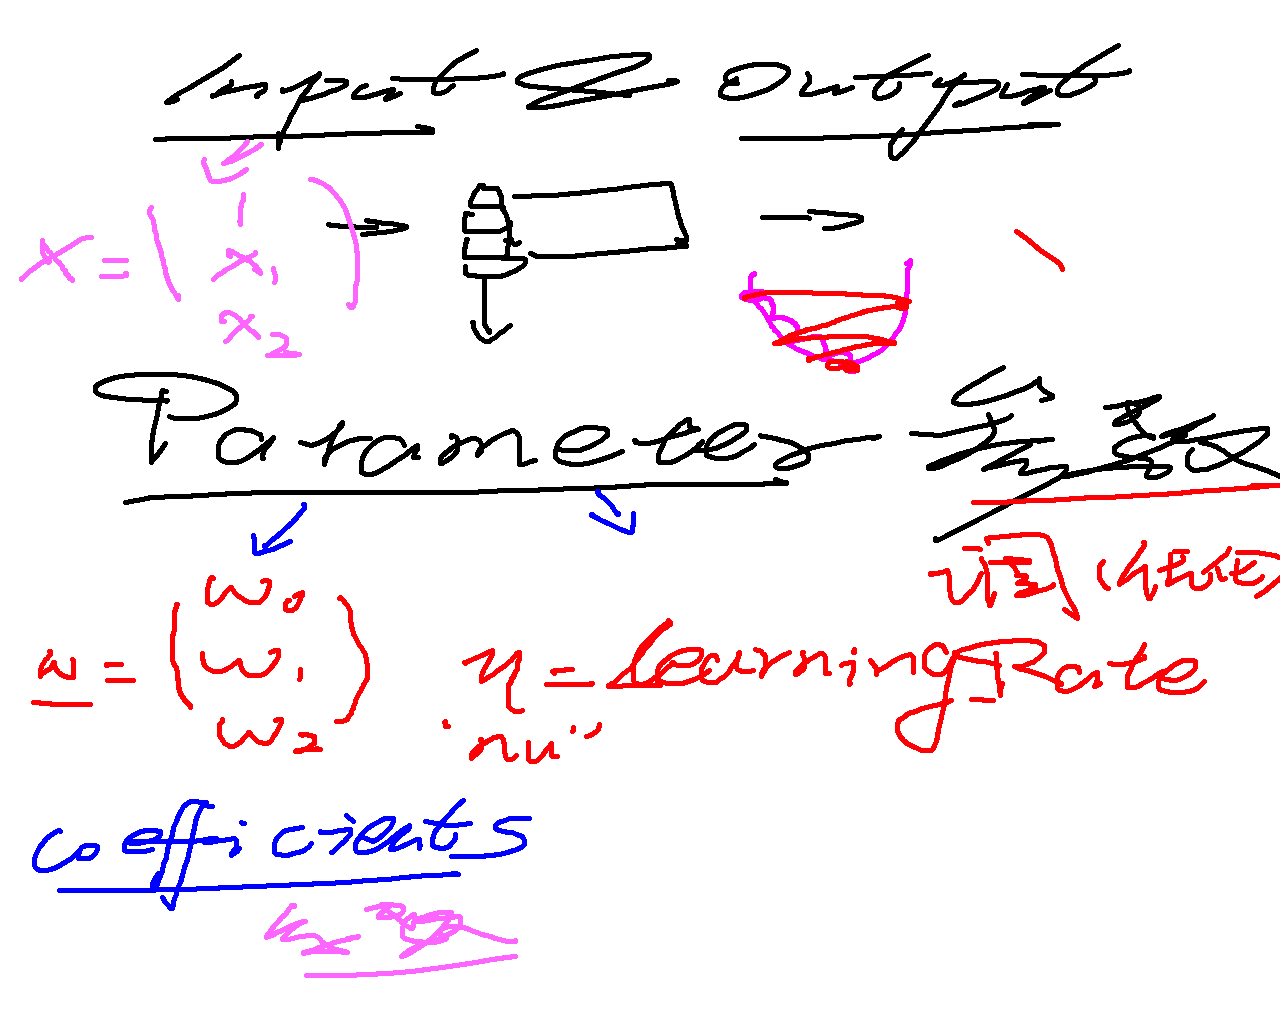

In [ ]:
from IPython.display import Image
Image(filename='1.9.extra.png')

## 4. The Perceptron Activation and Prediction Rule

The perceptron algorithm computes:

$$ \text{activation} = \text{bias} + \sum_{i=1}^{n} w_{i} \cdot x_{i} $$

Then applies a **step function**:

$$\text{prediction} = \begin{cases} 1 & \text{if activation} \geq 0 \\ 0 & \text{otherwise} \end{cases}$$

This is the simplest possible activation function — a hard threshold.

## 5. Learning Rule: Stochastic Gradient Descent

The perceptron uses **stochastic gradient descent (SGD)** to optimize its weights. After each prediction, if an error is made, the weights are updated:

$$ w = w + \text{learning\_rate} \times (\text{expected} - \text{predicted}) \times x $$

- **learning rate**: controls the magnitude of each weight update step
- **epochs**: the number of complete passes through the training data

If the prediction is correct (`expected == predicted`), the error term is 0 and no update occurs.

## 6. Implementation

### The `predict` function

Given a data row and a weight vector, compute the activation and return a binary prediction.

In [ ]:
def predict(row, weights):
    activation = weights[0]  # bias term
    for i in range(len(row) - 1):
        activation += weights[i + 1] * row[i]
    return 1.0 if activation >= 0.0 else 0.0

### Testing with sample data

Let's test the `predict` function with some sample binary-class data and manually chosen weights. This is a linear model:

$$ \text{activation} = w_1 \cdot X_1 + w_2 \cdot X_2 + \text{bias} $$

$$ \text{activation} = 0.569 \cdot X_1 + (-2.38) \cdot X_2 + 2.0 $$

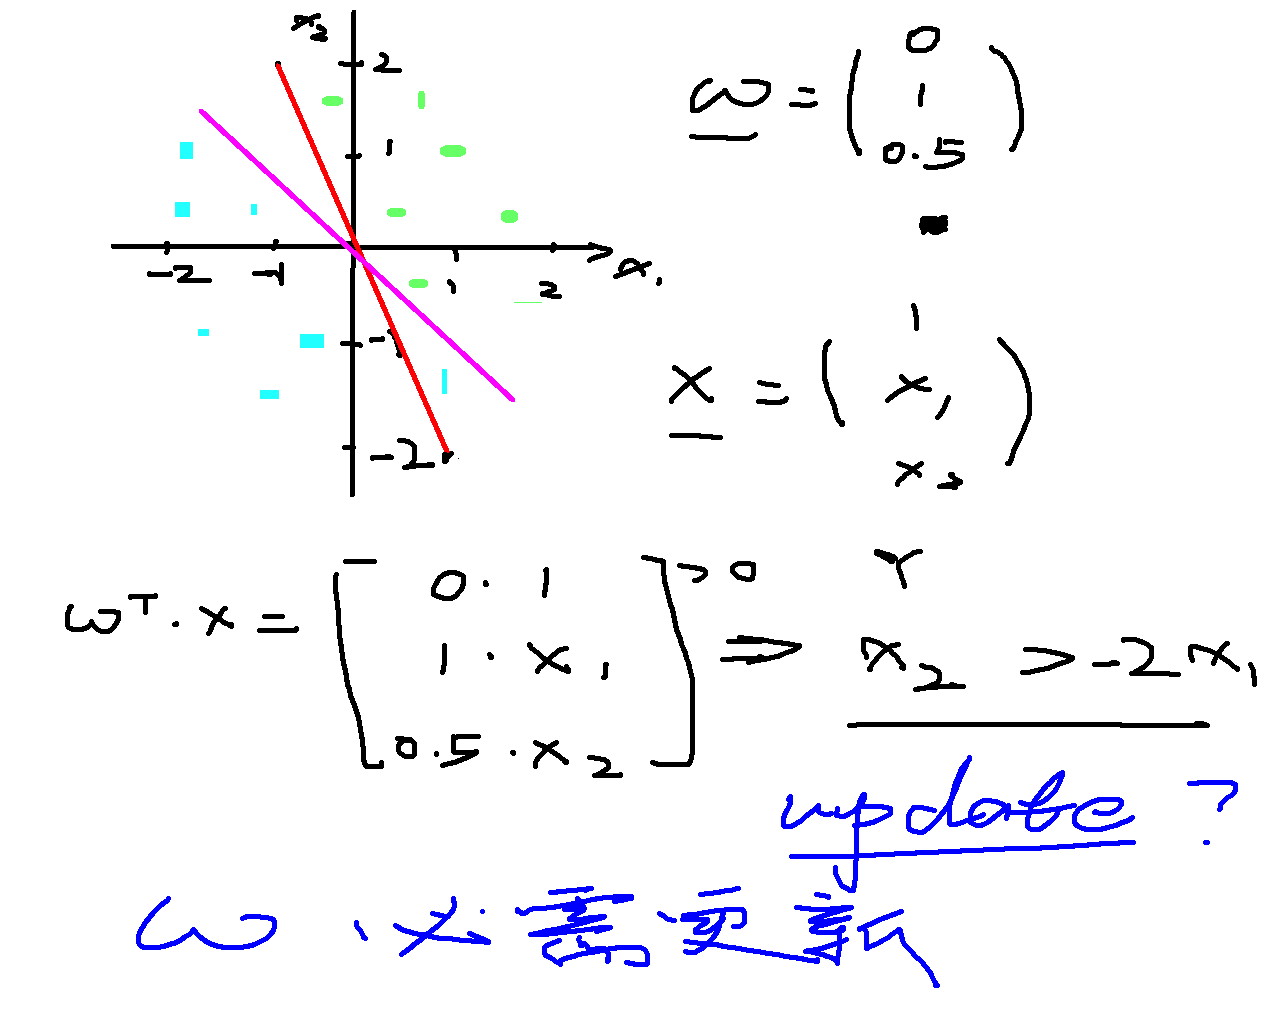

In [ ]:
# Sample binary classification data: [feature1, feature2, class_label]
dataset = [[2.78, 2.55, 0],
           [1.47, 2.36, 0],
           [1.39, 1.85, 0],
           [3.06, 3.01, 0],
           [7.63, 2.76, 0],
           [5.33, 2.09, 1],
           [6.93, 1.76, 1],
           [8.76, -0.77, 1],
           [7.66, 2.46, 1]]

# Manually chosen weights: [bias, w1, w2]
weights = [2.0, 0.569, -2.38]

for row in dataset:
    prediction = predict(row, weights)
    print("Expected: %d, Predicted: %d" % (row[-1], prediction))

## 7. Training the Perceptron

The training loop involves three nested iterations:

1. **Epoch loop**: repeat the entire training process for a specified number of epochs
2. **Row loop**: for each epoch, iterate through every training example
3. **Weight update loop**: for each misclassified example, update every weight

The update formulas are:

$$ w_i(t+1) = w_i(t) + \text{learning\_rate} \times (\text{expected}(t) - \text{predicted}(t)) \times x_i(t) $$

$$ \text{bias}(t+1) = \text{bias}(t) + \text{learning\_rate} \times (\text{expected}(t) - \text{predicted}(t)) $$

In [ ]:
def opt_weights(train, learning_rate, how_many_epoch):
    weights = [0.0 for i in range(len(train[0]))]
    for epoch in range(how_many_epoch):
        sum_error = 0
        for row in train:
            prediction = predict(row, weights)
            error = row[-1] - prediction
            sum_error += error ** 2
            # Update bias
            weights[0] = weights[0] + learning_rate * error
            # Update feature weights
            for i in range(len(row) - 1):
                weights[i + 1] = weights[i + 1] + learning_rate * error * row[i]
        print('Epoch: %d, Learning Rate: %.4f, Error: %.4f' % (epoch, learning_rate, sum_error))
    return weights

### Summary

The perceptron is a foundational algorithm that illustrates core ML concepts:
- **Linear decision boundaries**
- **Iterative weight optimization** via gradient descent
- **Convergence guarantees** for linearly separable data

Despite its simplicity, the perceptron laid the groundwork for modern neural networks and deep learning.